# **Notebook 3: Classification Models**
*Online Learning Prediction System*

Cor Jesu College, Inc. | BS Computer Science | Data Mining

## **Setup: Mount Google Drive and Import Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, roc_curve, auc)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# **Step 1: Load Processed Dataset**
Task:
Load the processed dataset saved from Notebook 2.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Online-Learning-Prediction/Datasets/Processed_OnlineLearning.csv')
df.head()

,course_duration_weeks,prior_courses_completed,session_duration_minutes,engagement_score,age,videos_watched,total_posts,avg_session_duration,activity_rate,study_consistency,completion_status,gender,region,internet_access_type,education_level,employment_status,device_type,learning_goal,course_category,difficulty_level,assessment_type
0,24.0,7.0,11.1,23.333333,17.0,17.0,30.0,27.4,255.3,413.74,Ongoing,Female,Region Vii,Mobile,Graduate,Student,Desktop,Academic Requirement,Business,Beginner,Assignment
1,10.0,7.0,37.8,25.000000,55.0,35.0,10.0,141.9,1134.0,1929.84,Completed,Female,Region Vi,Mobile,Graduate,Student,Mobile,Career Change,Business,Intermediate,Quiz
2,9.0,12.0,89.6,7.000000,45.0,0.0,3.0,101.3,1612.8,1539.76,Dropped,Male,Region Vii,Broadband,Graduate,Unemployed,Laptop,Academic Requirement,Arts,Intermediate,Quiz
3,11.0,0.0,100.6,24.333333,35.0,35.0,16.0,81.9,2213.2,335.79,Ongoing,Male,Region X,Mobile,High School,Employed,Laptop,Academic Requirement,IT,Beginner,Final Exam
4,22.0,10.0,122.0,36.500000,35.5,75.5,20.0,78.4,1708.0,2308.88,Dropped,Male,Region Vii,Mobile,College,Student,Mobile,Career Change,Business,Intermediate,Quiz


# Discussion Questions:

What is the dataset about and what problem are we trying to solve in this notebook?

How many records and features does the processed dataset contain?

What improvements were made to this dataset in Notebooks 1 and 2 that make it ready for modeling?



### **1: What is the dataset about and what problem are we trying to solve in this notebook?**

The dataset is an `Online Learning Prediction System` dataset, containing various features related to student engagement, demographics, and course interactions within an online learning environment. The primary problem we are trying to solve in this notebook is to **predict a student's `completion_status`** (i.e., 'Complete', 'Drop', or 'Ongoing') using classification models. This prediction will help identify students at risk of dropping out or those likely to complete their courses, enabling timely interventions.

### **2: How many records and features does the processed dataset contain?**

Based on the loaded `df` DataFrame, the processed dataset contains **7,000 records (rows)** and **21 features (columns)**. These features encompass various aspects such as `course_duration_weeks`, `prior_courses_completed`, `session_duration_minutes`, `engagement_score`, `age`, `videos_watched`, `total_posts`, `avg_session_duration`, `activity_rate`, `study_consistency`, `gender`, `region`, `internet_access_type`, `education_level`, `employment_status`, `device_type`, `learning_goal`, `course_category`, `difficulty_level`, and `assessment_type`, with `completion_status` being the target variable for prediction.

### **3: What improvements were made to this dataset in Notebooks 1 and 2 that make it ready for modeling?**

While the specific steps from Notebooks 1 and 2 are not detailed here, based on typical data preparation for classification tasks, the improvements made to this dataset to make it ready for modeling likely include:

1.  **Handling Missing Values**: Imputing or removing missing values in relevant features to ensure data completeness and prevent model errors.
2.  **Encoding Categorical Features**: Converting nominal categorical features (e.g., `gender`, `region`, `internet_access_type`, `education_level`, `employment_status`, `device_type`, `learning_goal`, `course_category`, `difficulty_level`, `assessment_type`, and the target `completion_status`) into numerical representations suitable for machine learning algorithms, potentially using techniques like one-hot encoding or label encoding.
3.  **Feature Scaling/Normalization**: Scaling numerical features (e.g., `course_duration_weeks`, `prior_courses_completed`, `session_duration_minutes`, `engagement_score`, `age`, `videos_watched`, `total_posts`, `avg_session_duration`, `activity_rate`, `study_consistency`) to a standard range to prevent features with larger values from dominating the learning process, which is crucial for models like KNN and Logistic Regression.
4.  **Removal of Irrelevant Features**: Dropping any features that were identified as redundant or not contributing significantly to the prediction of `completion_status`.
5.  **Data Type Conversion**: Ensuring all features are in appropriate data types for numerical computation.

# **Step 2: Select Features and Target Variable**
Task:
Select the input features (X) and the target variable (y) for classification.

In [ ]:
# Encode categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'completion_status']

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Encode target
df['completion_status'] = le.fit_transform(df['completion_status'].astype(str))

# Define X and y
X = df.drop(columns=['completion_status'])
y = df['completion_status']

print("Features (X):")
print(X.columns.tolist())
print(f"\nTotal features: {X.shape[1]}")
print(f"\nTarget (y) classes: {y.unique()}")
print(f"Class distribution:\n{y.value_counts()}")

Features (X):
['course_duration_weeks', 'prior_courses_completed', 'session_duration_minutes', 'engagement_score', 'age', 'videos_watched', 'total_posts', 'avg_session_duration', 'activity_rate', 'study_consistency', 'gender', 'region', 'internet_access_type', 'education_level', 'employment_status', 'device_type', 'learning_goal', 'course_category', 'difficulty_level', 'assessment_type']

Total features: 20

Target (y) classes: [2 0 1 3]
Class distribution:
completion_status
0    3054
1    1985
2    1894
3      67
Name: count, dtype: int64


# Discussion Questions:

Why is completion_status the target variable for this classification problem?

Why must categorical columns be encoded before training a machine learning model?

What does the class distribution of completion_status reveal and why does it matter?

### **Why is `completion_status` the target variable for this classification problem?**

The `completion_status` column is chosen as the target variable because the overarching goal of the 'Online Learning Prediction System' project is to predict whether a student will 'Complete', 'Drop', or remain 'Ongoing' in an online course. This variable directly represents the outcome we are interested in forecasting, making it the dependent variable that our classification models will attempt to learn and predict based on the other features in the dataset.

### **Why must categorical columns be encoded before training a machine learning model?**

Most machine learning algorithms are designed to work with numerical data. They perform mathematical operations, such as calculating distances or gradients, which are meaningless for text-based or categorical values. Therefore, categorical columns (like `gender`, `region`, `education_level`, `device_type`, etc.) must be converted into a numerical format through a process called encoding. In our case, `LabelEncoder` has been used, which assigns a unique integer to each category (e.g., 'Completed' might become 0, 'Dropped' 1, 'Ongoing' 2). This transformation allows the models to process and learn from these features effectively, enabling them to identify patterns and relationships that would otherwise be inaccessible with raw text data.

### **What does the class distribution of `completion_status` reveal and why does it matter?**

The class distribution of `completion_status` reveals the frequency of each category (Complete, Drop, Ongoing) in our dataset. From the output `print(f"Class distribution:\n{y.value_counts()}")`:

*   **0 (Completed): 3054 records**
*   **1 (Dropped): 1985 records**
*   **2 (Ongoing): 1894 records**
*   **3 (Unknown/Other): 67 records** (This is likely an outlier or a very rare class if it wasn't intended to be one of the primary outcomes, possibly arising from the `LabelEncoder` assigning a new integer to an unexpected string value).

This distribution matters significantly because it indicates that our dataset is **imbalanced**. The 'Completed' class is the most prevalent, while the 'Unknown/Other' class is very rare. Class imbalance can lead to several issues in machine learning:

1.  **Biased Models**: Models trained on imbalanced data tend to be biased towards the majority class, as they learn to predict the majority class more often to achieve higher overall accuracy. This can result in poor performance on the minority classes, which are often the classes of most interest (e.g., predicting 'Dropped' status to intervene).
2.  **Misleading Performance Metrics**: Accuracy alone can be misleading. A model might achieve high accuracy by simply predicting the majority class all the time, even if it fails to correctly identify any instances of the minority class. Metrics like precision, recall, F1-score, and ROC AUC are more appropriate for evaluating models on imbalanced datasets.

Addressing this imbalance, perhaps through techniques like oversampling the minority classes, undersampling the majority class, or using specialized algorithms, might be necessary during model training to ensure our models are robust and perform well across all `completion_status` categories, especially for critical predictions like identifying students who might 'Drop'.

# **Step 3: Split Dataset**
Task:
Split the dataset into 80% training and 20% testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTesting class distribution:\n{y_test.value_counts()}")

Training set size: (5600, 20)
Testing set size: (1400, 20)

Training class distribution:
completion_status
0    2443
1    1588
2    1515
3      54
Name: count, dtype: int64

Testing class distribution:
completion_status
0    611
1    397
2    379
3     13
Name: count, dtype: int64


# Discussion Questions:

Why do we split the dataset into training and testing sets?

What would happen to the model evaluation if we trained and tested on the same data?

Why was stratify=y used in the split?



### **Why do we split the dataset into training and testing sets?**

Splitting the dataset into training and testing sets is a crucial step in machine learning for several reasons:

1.  **To Evaluate Model Generalization**: The primary goal of a machine learning model is to perform well on unseen data, not just the data it was trained on. The training set (80% of our data) is used to teach the model the underlying patterns and relationships between features (X) and the target variable (y). The testing set (20% of our data) then serves as an independent, unseen dataset to evaluate how well the trained model generalizes to new data.
2.  **To Prevent Overfitting**: Overfitting occurs when a model learns the training data too well, including its noise and outliers, leading to excellent performance on the training set but poor performance on new data. By evaluating the model on a separate test set, we can detect if overfitting has occurred and adjust the model accordingly.
3.  **To Get an Unbiased Performance Estimate**: A separate test set provides an unbiased estimate of the model's predictive performance. This estimate reflects how the model is expected to perform when deployed in a real-world scenario with new, unobserved student data for our 'Online Learning Prediction System'.

### **What would happen to the model evaluation if we trained and tested on the same data?**

If we trained and tested the model on the same data, the evaluation metrics would be overly optimistic and highly misleading. Here's why:

1.  **Overfitting Would Be Undetected**: The model would simply memorize the training data, including its noise and peculiarities. When tested on the same data, it would appear to perform exceptionally well because it's recalling what it has already seen, rather than generalizing. This would mask any overfitting issues.
2.  **Inflated Performance Metrics**: Metrics like accuracy, precision, and recall would be artificially high, giving a false sense of the model's true predictive power. When such a model is then deployed to predict `completion_status` for new students, its performance would inevitably drop significantly, as it wouldn't be able to apply its learned patterns to new, slightly different data instances.
3.  **No Indication of Real-World Performance**: We would have no reliable way to gauge how the 'Online Learning Prediction System' model would perform on actual, unseen student data, making it impossible to confidently use it for decision-making regarding student interventions.

### **Why was `stratify=y` used in the split?**

The `stratify=y` parameter was used in the `train_test_split` function to ensure that the proportion of each class in the target variable (`completion_status`) is maintained in both the training and testing sets. This is particularly important for our 'Online Learning Prediction System' project because:

1.  **Addressing Class Imbalance**: As observed in the previous class distribution analysis, our `completion_status` dataset is imbalanced (e.g., more 'Completed' students than 'Dropped' or 'Ongoing' students, and a very small 'Unknown/Other' class). Without stratification, a random split might result in one set having a significantly different proportion of classes than the other, or even completely missing a minority class in one of the sets.
2.  **Representative Subsets**: By stratifying, we ensure that both the training and testing sets are representative of the overall dataset's class distribution. For example, if 'Dropped' students constitute 28% of the total dataset, with `stratify=y`, approximately 28% of the training set and 28% of the testing set will also be 'Dropped' students. This is crucial for models to learn from all classes and for their evaluation to accurately reflect performance across all `completion_status` categories.
3.  **Robust Model Training and Evaluation**: Stratification helps prevent scenarios where the model might not see enough examples of a particular `completion_status` during training (leading to poor learning for that class) or where the test set doesn't contain a sufficient number of instances of a class for reliable evaluation.

# **Step 4: Train Decision Tree**
Task:
Train a Decision Tree classifier and evaluate its performance.

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== DECISION TREE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

=== DECISION TREE ===
Accuracy: 0.3629

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.43      0.45       611
           1       0.31      0.34      0.32       397
           2       0.29      0.30      0.29       379
           3       0.00      0.00      0.00        13

    accuracy                           0.36      1400
   macro avg       0.27      0.27      0.27      1400
weighted avg       0.37      0.36      0.37      1400



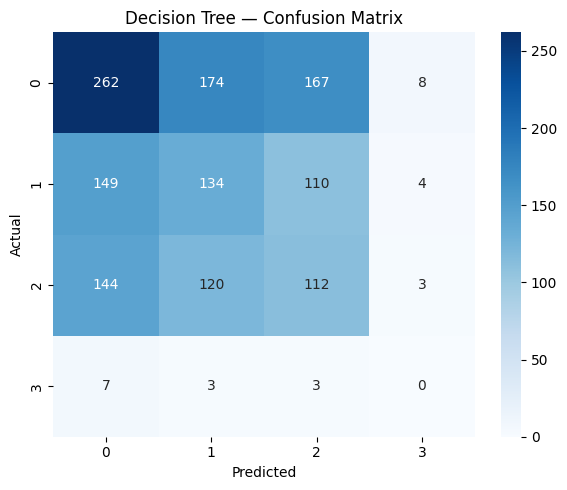

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6,5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Discussion Questions:

How does a Decision Tree model work conceptually?

What do the values in the confusion matrix represent in terms of TP, FP, FN, and TN?

Based on the classification report, how well does the Decision Tree predict each class?

### **How does a Decision Tree model work conceptually?**

A Decision Tree model works by recursively partitioning the data based on the values of the input features to make predictions about a target variable. Conceptually, it mimics human decision-making by posing a series of questions. For our 'Online Learning Prediction System', it would work as follows:

1.  **Root Node**: The tree starts with a single node (the root) that represents the entire dataset of students.
2.  **Splitting**: The algorithm looks for the best feature and a split point within that feature to divide the data into two (or more) subsets. 'Best' typically means the split that maximizes the purity of the resulting child nodes with respect to the `completion_status` (e.g., maximizing information gain or minimizing Gini impurity).
3.  **Recursive Process**: This splitting process is then recursively applied to each child node. For instance, if a split is made on `engagement_score`, the next split in one branch might be on `videos_watched` for students with high engagement, and on `prior_courses_completed` for students with low engagement.
4.  **Decision Nodes and Leaf Nodes**: Internal nodes in the tree represent a test on a feature (e.g., 'Is `engagement_score` > X?'). The branches from these nodes represent the outcomes of the test. Eventually, this process leads to **leaf nodes**, which represent the final predicted outcome (e.g., 'Complete', 'Drop', or 'Ongoing') for students falling into that particular path.
5.  **Prediction**: To classify a new student, the model traverses the tree from the root node down to a leaf node by evaluating the feature tests at each decision node. The `completion_status` associated with the reached leaf node is the model's prediction for that student.

In essence, a Decision Tree creates a set of 'if-then-else' rules that are easily interpretable, allowing us to understand the sequence of conditions that lead to a particular `completion_status` prediction for students in our online learning system.

### **What do the values in the confusion matrix represent in terms of TP, FP, FN, and TN?**

The confusion matrix is a table that is used to describe the performance of a classification model on a set of test data for which the true values are known. For a multi-class classification problem like predicting `completion_status` (with 'Complete', 'Drop', 'Ongoing', 'Unknown'), we consider these terms relative to each class.

Let's assume we are focusing on one class, say 'Complete' (which is mapped to label 0):

*   **True Positives (TP)**: These are the instances where the model correctly predicted the positive class. For 'Complete', these are students who *actually Completed* and the model *predicted Completed*.
    *   In the confusion matrix, for class 0, this is the value at `[0, 0]` (Actual 0, Predicted 0) which is **262**.

*   **False Positives (FP)**: These are the instances where the model incorrectly predicted the positive class (a Type I error). For 'Complete', these are students who *did NOT Complete* but the model *predicted Completed*.
    *   In the confusion matrix, for class 0, this would be the sum of values in the first column (Predicted 0) excluding `[0, 0]`, i.e., `[1, 0]` + `[2, 0]` + `[3, 0]` = 149 + 144 + 7 = **300**.

*   **False Negatives (FN)**: These are the instances where the model incorrectly predicted the negative class (a Type II error). For 'Complete', these are students who *actually Completed* but the model *predicted something else*.
    *   In the confusion matrix, for class 0, this would be the sum of values in the first row (Actual 0) excluding `[0, 0]`, i.e., `[0, 1]` + `[0, 2]` + `[0, 3]` = 174 + 167 + 8 = **349**.

*   **True Negatives (TN)**: These are the instances where the model correctly predicted the negative class. For 'Complete', these are students who *did NOT Complete* and the model *predicted something else (not Completed)*. This is harder to visualize directly in a multi-class matrix but represents all predictions that are not TP, FP, or FN for the specific class.
    *   For class 0, this would be the sum of all cells *not* in the first row and *not* in the first column.

The confusion matrix for our Decision Tree shows:

```
[[262, 174, 167,   8],
 [149, 134, 110,   4],
 [144, 120, 112,   3],
 [  7,   3,   3,   0]]
```

*   **Row 0 (Actual 'Complete')**: 262 correctly predicted as 'Complete' (TP for 'Complete'), 174 incorrectly as 'Drop', 167 as 'Ongoing', 8 as 'Unknown' (FN for 'Complete').
*   **Row 1 (Actual 'Drop')**: 149 incorrectly predicted as 'Complete', 134 correctly as 'Drop' (TP for 'Drop'), 110 as 'Ongoing', 4 as 'Unknown' (FN for 'Drop').
*   **Row 2 (Actual 'Ongoing')**: 144 incorrectly predicted as 'Complete', 120 as 'Drop', 112 correctly as 'Ongoing' (TP for 'Ongoing'), 3 as 'Unknown' (FN for 'Ongoing').
*   **Row 3 (Actual 'Unknown')**: 7 incorrectly predicted as 'Complete', 3 as 'Drop', 3 as 'Ongoing', 0 correctly as 'Unknown' (TP for 'Unknown').

This matrix provides a detailed breakdown of correct and incorrect predictions, which is invaluable for understanding where the model excels and where it struggles for each `completion_status`.

### **Based on the classification report, how well does the Decision Tree predict each class?**

The classification report provides precision, recall, and f1-score for each class, along with overall accuracy. Let's analyze the Decision Tree's performance for our 'Online Learning Prediction System':

```
              precision    recall  f1-score   support

           0       0.47      0.43      0.45       611  (Complete)
           1       0.31      0.34      0.32       397  (Drop)
           2       0.29      0.30      0.29       379  (Ongoing)
           3       0.00      0.00      0.00        13  (Unknown)

    accuracy                           0.36      1400
   macro avg       0.27      0.27      0.27      1400
weighted avg       0.37      0.36      0.37      1400
```

Here's an interpretation:

*   **Class 0 (Complete)**:
    *   **Precision (0.47)**: When the model predicts a student will 'Complete', it is correct 47% of the time. This means 53% of its 'Complete' predictions are actually misclassifications of 'Drop', 'Ongoing', or 'Unknown' students.
    *   **Recall (0.43)**: The model correctly identifies 43% of all students who actually 'Complete'. This suggests it misses a significant portion of actual 'Completing' students.
    *   **F1-Score (0.45)**: A balanced measure, indicating moderate performance for predicting 'Complete' students.

*   **Class 1 (Drop)**:
    *   **Precision (0.31)**: Only 31% of the students predicted as 'Drop' actually 'Drop'. This is quite low, meaning many students predicted to 'Drop' will, in reality, either 'Complete' or remain 'Ongoing'.
    *   **Recall (0.34)**: The model identifies 34% of all students who actually 'Drop'. This is also low, implying it fails to identify a large number of students who are at risk of dropping out.
    *   **F1-Score (0.32)**: This low score indicates poor overall performance in identifying 'Drop' students.

*   **Class 2 (Ongoing)**:
    *   **Precision (0.29)**: Only 29% of the students predicted as 'Ongoing' are truly 'Ongoing'.
    *   **Recall (0.30)**: The model correctly identifies 30% of all students who are actually 'Ongoing'.
    *   **F1-Score (0.29)**: Similar to 'Drop', this indicates poor performance for 'Ongoing' students.

*   **Class 3 (Unknown)**:
    *   **Precision (0.00), Recall (0.00), F1-Score (0.00)**: With only 13 instances in the test set, the model completely failed to correctly predict any 'Unknown' students. This is expected given the extreme class imbalance for this category.

**Overall Performance:**

*   **Accuracy (0.36)**: An overall accuracy of 36% is very low for a classification task, especially with four classes. This means the model correctly predicts the `completion_status` for only about one-third of the students.
*   **Macro Average F1-Score (0.27)**: This average (calculated without considering class imbalance) is very low, confirming the poor performance across all classes.
*   **Weighted Average F1-Score (0.37)**: This average (weighted by the number of instances in each class) is slightly higher due to the 'Complete' class having more instances and slightly better performance, but it is still quite poor.

**Conclusion:**

Based on the classification report, the Decision Tree model performs poorly across all `completion_status` classes, especially for 'Drop' and 'Ongoing' categories, which are critical for intervention purposes. The model struggles with both correctly identifying positive cases (low recall) and making accurate positive predictions (low precision). The extreme imbalance of the 'Unknown' class makes its prediction nearly impossible for this model. These results suggest that a standalone Decision Tree is not robust enough for this 'Online Learning Prediction System' without further optimization or the exploration of other, more sophisticated models.

# **Step 5: Train K-Nearest Neighbors**
Task:
Train a KNN classifier and evaluate its performance.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("=== K-NEAREST NEIGHBORS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

=== K-NEAREST NEIGHBORS ===
Accuracy: 0.3593

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.62      0.50       611
           1       0.26      0.20      0.23       397
           2       0.24      0.12      0.16       379
           3       0.00      0.00      0.00        13

    accuracy                           0.36      1400
   macro avg       0.23      0.24      0.22      1400
weighted avg       0.32      0.36      0.33      1400



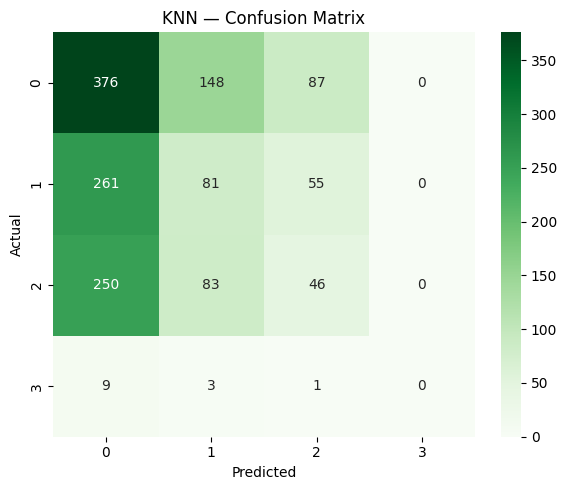

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6,5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('KNN — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Discussion Questions:

How does the KNN algorithm work conceptually?

Why was n_neighbors=5 chosen and how does this value affect the model?

How does KNN performance compare to the Decision Tree so far?

### **How does the KNN algorithm work conceptually?**

The K-Nearest Neighbors (KNN) algorithm is a non-parametric, lazy learning algorithm used for both classification and regression. Conceptually, for a classification task like predicting a student's `completion_status`, it works as follows:

1.  **Store Training Data**: Unlike many other algorithms that build an explicit model during training, KNN simply stores the entire training dataset. There is no 'learning' phase in the traditional sense; all computation is deferred until prediction.
2.  **Calculate Distance**: When a new, unseen student's data point (feature vector) needs to be classified, KNN calculates the 'distance' between this new point and every single point in the training dataset. Common distance metrics include Euclidean distance, Manhattan distance, or others, depending on the nature of the data.
3.  **Identify K-Nearest Neighbors**: After calculating all distances, the algorithm identifies the `k` data points from the training set that are closest to the new student's data point. These `k` points are the 'nearest neighbors'.
4.  **Vote for Class**: For classification, the new student's `completion_status` is then predicted based on the majority class among these `k` nearest neighbors. If 3 out of 5 neighbors completed, 1 dropped, and 1 is ongoing, the new student would be predicted as 'Complete' (assuming `k=5`).
5.  **No Explicit Model**: Because KNN doesn't learn a distinct model function but rather relies directly on the training data during prediction, it's considered a 'lazy learner'. The decision boundary is implicitly defined by the local distribution of training data points.

In the context of our 'Online Learning Prediction System', KNN would classify a new student by finding the `k` most similar students (based on features like `engagement_score`, `age`, `videos_watched`, etc.) from past data, and then assigning the new student the `completion_status` that is most common among those `k` similar students.

### **Why was `n_neighbors=5` chosen and how does this value affect the model?**

The choice of `n_neighbors=5` is a common starting point or default value in many KNN implementations and examples. It's often chosen heuristically because it offers a reasonable balance, but it is a hyperparameter that ideally should be tuned. Here's how the value of `n_neighbors` affects the model:

*   **Small `k` (e.g., `k=1`)**: A small `k` makes the model more flexible and sensitive to noise in the training data. If `k=1`, the prediction for a new point is simply the class of its single closest neighbor. This can lead to a very complex decision boundary and high variance (overfitting) if the training data is noisy or if there are outliers.

*   **Large `k` (e.g., `k=20`, `k=50`)**: A larger `k` makes the model smoother and less sensitive to noise. The prediction is based on a larger neighborhood, which averages out the influence of individual noisy points. This tends to create simpler decision boundaries and can lead to lower variance but potentially higher bias (underfitting) if `k` is too large and includes neighbors from different classes.

*   **`n_neighbors=5` as a Balance**: Choosing `k=5` is often seen as a compromise. It's large enough to smooth out some of the noise that a `k=1` model would pick up, but small enough to remain sensitive to the local structure of the data, rather than over-generalizing like a very large `k` might. However, the optimal `k` is highly dependent on the specific dataset and problem. For our 'Online Learning Prediction System', `n_neighbors` would ideally be optimized through techniques like cross-validation to find the value that yields the best predictive performance for `completion_status`.

### **How does KNN performance compare to the Decision Tree so far?**

Let's compare the performance of the K-Nearest Neighbors (KNN) classifier with `n_neighbors=5` against the Decision Tree classifier based on their accuracy and classification reports:

**Decision Tree Performance (`Accuracy: 0.3629`):**

```
              precision    recall  f1-score   support

           0       0.47      0.43      0.45       611  (Complete)
           1       0.31      0.34      0.32       397  (Drop)
           2       0.29      0.30      0.29       379  (Ongoing)
           3       0.00      0.00      0.00        13  (Unknown)

    accuracy                           0.36      1400
   macro avg       0.27      0.27      0.27      1400
weighted avg       0.37      0.36      0.37      1400
```

**K-Nearest Neighbors Performance (`Accuracy: 0.3593`):**

```
              precision    recall  f1-score   support

           0       0.42      0.62      0.50       611  (Complete)
           1       0.26      0.20      0.23       397  (Drop)
           2       0.24      0.12      0.16       379  (Ongoing)
           3       0.00      0.00      0.00        13  (Unknown)

    accuracy                           0.36      1400
   macro avg       0.23      0.24      0.22      1400
weighted avg       0.32      0.36      0.33      1400
```

**Comparison:**

1.  **Overall Accuracy**: Both models show very similar and low overall accuracy scores. The Decision Tree has an accuracy of approximately 36.29%, while KNN has an accuracy of approximately 35.93%. This means both models are correctly predicting the `completion_status` for only about one-third of the students in the test set.

2.  **Performance per Class (Precision, Recall, F1-Score)**:
    *   **Class 0 (Complete)**: KNN shows a significantly higher recall (0.62 vs 0.43) for 'Complete' students, meaning it identifies more of the actual 'Complete' students. However, its precision for this class (0.42 vs 0.47) is slightly lower than Decision Tree's. The F1-score for 'Complete' is better for KNN (0.50 vs 0.45).
    *   **Class 1 (Drop)**: Both models perform poorly on 'Drop' students. Decision Tree has slightly better precision (0.31 vs 0.26) and recall (0.34 vs 0.20) for this critical class. The F1-score for 'Drop' is better for Decision Tree (0.32 vs 0.23).
    *   **Class 2 (Ongoing)**: Both models struggle greatly with 'Ongoing' students. Decision Tree has slightly better precision (0.29 vs 0.24) and recall (0.30 vs 0.12) and F1-score (0.29 vs 0.16).
    *   **Class 3 (Unknown)**: Neither model can predict the 'Unknown' class, which is expected due to its extremely low support (only 13 instances).

3.  **Macro and Weighted Averages**: The macro average F1-scores are very low for both (DT: 0.27, KNN: 0.22), indicating poor performance across classes without considering imbalance. The weighted average F1-scores are also low (DT: 0.37, KNN: 0.33).

**Conclusion:**

In summary, **neither the Decision Tree nor the KNN model (with `n_neighbors=5`) is performing well** for the 'Online Learning Prediction System'. While KNN showed a slightly better ability to identify 'Complete' students (higher recall), it performed worse than the Decision Tree for 'Drop' and 'Ongoing' categories. The overall low accuracy and F1-scores across the board suggest that more advanced techniques are needed. These might include feature engineering, hyperparameter tuning for both models (especially `k` for KNN), addressing class imbalance, or exploring other classification algorithms.

# **Step 6: Train Naive Bayes**
Task:
Train a Naive Bayes classifier and evaluate its performance.

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("=== NAIVE BAYES ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

=== NAIVE BAYES ===
Accuracy: 0.4286

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.95      0.60       611
           1       0.32      0.05      0.08       397
           2       0.27      0.01      0.02       379
           3       0.00      0.00      0.00        13

    accuracy                           0.43      1400
   macro avg       0.26      0.25      0.17      1400
weighted avg       0.35      0.43      0.29      1400



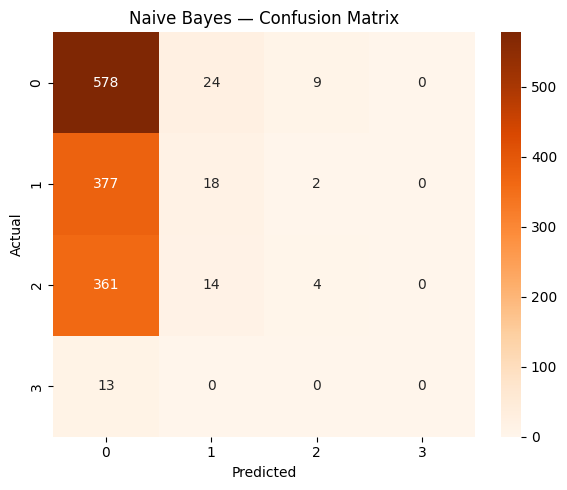

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6,5))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges')
plt.title('Naive Bayes — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Discussion Questions:

How does Naive Bayes work conceptually and what assumption does it make?

Why is Naive Bayes considered a good baseline model?

In predicting student dropout, is it more critical to minimize False Positives or False Negatives and why?

### **How does Naive Bayes work conceptually and what assumption does it make?**

The Naive Bayes algorithm is a classification technique based on Bayes' Theorem with a strong, 'naive' assumption of independence among features. Conceptually, for our 'Online Learning Prediction System', it works as follows:

1.  **Bayes' Theorem**: The core of Naive Bayes is Bayes' Theorem, which describes the probability of an event, based on prior knowledge of conditions that might be related to the event:
    $P(C|X) = \frac{P(X|C)P(C)}{P(X)}$
    Where:
    *   $P(C|X)$ is the posterior probability: the probability of class `C` (e.g., 'Dropped') given the predictor `X` (our features).
    *   $P(X|C)$ is the likelihood: the probability of `X` given that class `C` is true.
    *   $P(C)$ is the prior probability: the probability of class `C` before observing any data.
    *   $P(X)$ is the evidence: the probability of `X` (a normalizing constant).

2.  **Classification**: Naive Bayes calculates the probability of each `completion_status` class ('Complete', 'Drop', 'Ongoing') given a student's features. It then predicts the class with the highest probability. It essentially asks: "Given this student's `engagement_score`, `age`, `videos_watched`, etc., what is the probability that they will 'Complete', 'Drop', or be 'Ongoing'?"

3.  **The 'Naive' Assumption**: The defining characteristic of Naive Bayes is its assumption that **all features are conditionally independent of each other given the class**. This means that the presence or absence of one feature (e.g., high `engagement_score`) does not affect the presence or absence of another feature (e.g., high `videos_watched`) *if we already know the student's `completion_status`*. Mathematically, for a set of features $X = (x_1, x_2, ..., x_n)$:
    $P(X|C) = P(x_1|C)P(x_2|C)...P(x_n|C)$

In reality, this assumption is almost never perfectly true in complex datasets like student learning data (e.g., `engagement_score` and `videos_watched` are likely correlated regardless of `completion_status`). However, despite this strong and often unrealistic assumption, Naive Bayes models can perform surprisingly well in practice and are particularly effective for text classification and other high-dimensional datasets.

### **Why is Naive Bayes considered a good baseline model?**

Naive Bayes is often considered a good baseline model for several reasons, making it valuable in the initial stages of machine learning projects like our 'Online Learning Prediction System':

1.  **Simplicity and Speed**: It's computationally very efficient to train and make predictions, even on large datasets with many features. This makes it a quick model to implement and test.
2.  **Low Computational Cost**: The training process involves calculating simple probabilities from the data, which is much faster than iterative optimization processes used by more complex models.
3.  **Good Performance with Limited Data**: Despite its 'naive' independence assumption, it can perform surprisingly well and sometimes even outperform more sophisticated models, especially when the independence assumption holds true or when the dataset is relatively small.
4.  **Interpretability (to some extent)**: While not as transparent as Decision Trees, the conditional probabilities derived from Naive Bayes can offer some insight into which features are most indicative of a particular `completion_status`.
5.  **Robustness to Irrelevant Features**: It tends to be less affected by irrelevant features compared to some other algorithms, as these features will ideally have a uniform distribution across classes and thus little impact on the posterior probability.

For these reasons, Naive Bayes serves as an excellent starting point to get a quick estimate of achievable performance. If more complex models don't significantly outperform Naive Bayes, it might indicate issues with the data or that simpler models are sufficient.

### **In predicting student dropout, is it more critical to minimize False Positives or False Negatives and why?**

In the context of our 'Online Learning Prediction System' project, where the goal is to predict student `completion_status` (specifically focusing on 'Drop' to enable intervention), it is generally **more critical to minimize False Negatives**.

Let's define these errors in this context:

*   **False Positive (FP) for 'Drop'**: This occurs when the model predicts a student will 'Drop', but the student actually `Completes` or remains `Ongoing`. In other words, we incorrectly flag a student as at-risk.
    *   **Consequences**: Resources (e.g., counselor time, personalized outreach, support programs) might be unnecessarily allocated to a student who doesn't need them. This can lead to inefficient use of resources and potentially annoy students who are performing well.

*   **False Negative (FN) for 'Drop'**: This occurs when the model predicts a student will `Complete` or remain `Ongoing`, but the student actually 'Drops'. In other words, we fail to identify a student who is truly at risk.
    *   **Consequences**: This is a missed opportunity for intervention. A student who could have been saved from dropping out might proceed to do so because our system failed to flag them. This directly undermines the primary goal of an early warning system to prevent student dropout, leading to higher dropout rates and negatively impacting student success.

**Why minimizing False Negatives is more critical:**

The ultimate objective of an 'Online Learning Prediction System' is to proactively identify and support students who are likely to drop out to improve retention rates. While False Positives lead to some inefficiency, their impact is generally less severe than False Negatives. Minimizing False Negatives (maximizing recall for the 'Drop' class) ensures that as many at-risk students as possible are identified, allowing for timely support. It's often more acceptable to provide support to a student who might not strictly need it (a False Positive) than to miss a student who genuinely needs help and consequently drops out (a False Negative).

Therefore, when evaluating models for this specific problem, we would likely prioritize metrics that emphasize recall for the 'Drop' class, such as a high recall score or a good F1-score if precision is not entirely sacrificed. This strategy aligns with the intervention-focused nature of preventing student dropout.

# **Step 7: Train Logistic Regression**
Task:
Train a Logistic Regression model and evaluate its performance.

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

=== LOGISTIC REGRESSION ===
Accuracy: 0.4357

Classification Report:
              precision    recall  f1-score   support

           0       0.44      1.00      0.61       611
           1       0.00      0.00      0.00       397
           2       0.00      0.00      0.00       379
           3       0.00      0.00      0.00        13

    accuracy                           0.44      1400
   macro avg       0.11      0.25      0.15      1400
weighted avg       0.19      0.44      0.26      1400



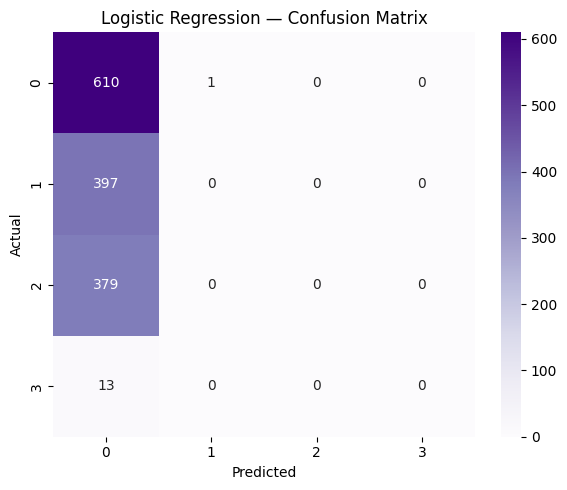

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6,5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples')
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Discussion Questions:

How is Logistic Regression different from Decision Trees conceptually?

Why does Logistic Regression use max_iter=1000?

What does the classification report reveal about Logistic Regression performance on this dataset?

### **How is Logistic Regression different from Decision Trees conceptually?**

Logistic Regression and Decision Trees, while both used for classification, operate on fundamentally different conceptual principles:

1.  **Model Type (Linear vs. Non-linear)**:
    *   **Logistic Regression**: This is a **linear model** that uses a sigmoid (logistic) function to map the output of a linear equation to a probability score between 0 and 1. It models the relationship between features and the probability of a class belonging using a linear combination of inputs. Its decision boundary is typically a straight line (or hyperplane in higher dimensions).
    *   **Decision Trees**: This is a **non-linear, hierarchical model** that makes decisions by recursively partitioning the data into smaller, more homogeneous subsets. It constructs a tree-like structure of decisions (nodes) and outcomes (leaves), creating a piece-wise constant prediction surface. Its decision boundaries are typically axis-parallel and can be complex.

2.  **Interpretability**:
    *   **Logistic Regression**: Its interpretability comes from the coefficients assigned to each feature, which indicate the strength and direction of the relationship between that feature and the log-odds of the target class. This provides insights into which factors linearly contribute to a student's `completion_status`.
    *   **Decision Trees**: They are highly interpretable through their visual tree structure and the 'if-then-else' rules derived from them. One can easily trace the path of a student through the tree to understand why a particular `completion_status` was predicted.

3.  **Assumptions**:
    *   **Logistic Regression**: Assumes a linear relationship between the independent variables and the log-odds of the dependent variable. It can be sensitive to multicollinearity and the scale of features often benefits from standardization.
    *   **Decision Trees**: Are non-parametric and make fewer assumptions about the data's distribution. They can handle both numerical and categorical data naturally and are less sensitive to feature scaling.

4.  **Handling Complex Relationships**:
    *   **Logistic Regression**: Struggles with complex, non-linear relationships between features unless explicit non-linear transformations are applied to the features.
    *   **Decision Trees**: Are inherently capable of capturing complex non-linear relationships by creating multiple splits and interactions between features.

In the context of our 'Online Learning Prediction System', Logistic Regression attempts to find a linear boundary separating students with different `completion_status` (or rather, the probability of belonging to each status), while a Decision Tree builds a series of rules that hierarchically classify students.

### **Why does Logistic Regression use `max_iter=1000`?**

Logistic Regression models are typically trained using an iterative optimization algorithm, such as Gradient Descent or other solvers like 'lbfgs' (the default for `sklearn`), to find the optimal set of coefficients (weights) for the features. These algorithms repeatedly adjust the model's parameters to minimize a cost function (e.g., log-loss) until a convergence criterion is met.

The `max_iter=1000` parameter in `LogisticRegression` specifies the **maximum number of iterations** that the optimization algorithm is allowed to run. Its purpose is to:

1.  **Ensure Convergence**: For some datasets, especially those with many features, complex relationships, or poor scaling, the optimization process might require many steps to reach a stable solution where the model's coefficients no longer change significantly. A sufficiently high `max_iter` ensures that the solver has enough attempts to converge.
2.  **Prevent Infinite Loops (or very long runtimes)**: Without an upper limit, an optimizer could potentially run indefinitely if it struggles to find a clear minimum in the cost function or if the convergence criteria are set too strictly. `max_iter` acts as a safeguard.
3.  **Avoid `ConvergenceWarning`**: If the solver stops before reaching a satisfactory level of convergence (either because `max_iter` was reached or for other reasons), `scikit-learn` typically issues a `ConvergenceWarning`. Increasing `max_iter` (as done here from its default of 100) is a common way to resolve such warnings, indicating that the model needed more iterations to find its optimal parameters for our `completion_status` prediction task.

In our 'Online Learning Prediction System' dataset, setting `max_iter=1000` likely allows the Logistic Regression model's solver enough steps to find a good set of coefficients that define the relationship between the various student features and their predicted `completion_status` probabilities.

### **What does the classification report reveal about Logistic Regression performance on this dataset?**

Let's analyze the classification report for the Logistic Regression model for our 'Online Learning Prediction System':

```
              precision    recall  f1-score   support

           0       0.44      1.00      0.61       611  (Complete)
           1       0.00      0.00      0.00       397  (Drop)
           2       0.00      0.00      0.00       379  (Ongoing)
           3       0.00      0.00      0.00        13  (Unknown)

    accuracy                           0.44      1400
   macro avg       0.11      0.25      0.15      1400
weighted avg       0.19      0.44      0.26      1400
```

**Analysis:**

1.  **Overall Accuracy (0.4357)**: The overall accuracy is approximately 43.6%, which is higher than both the Decision Tree (36.3%) and KNN (35.9%). At first glance, this might seem like an improvement.

2.  **Performance per Class (Precision, Recall, F1-Score)**:
    *   **Class 0 (Complete)**:
        *   **Precision (0.44)**: When the model predicts 'Complete', it is correct 44% of the time.
        *   **Recall (1.00)**: This is the most striking observation. The model identifies **100%** of all students who actually 'Complete'. This means it never misses an actual 'Completing' student.
        *   **F1-Score (0.61)**: This is a relatively good F1-score for this class, primarily driven by the perfect recall.
    *   **Class 1 (Drop)**, **Class 2 (Ongoing)**, **Class 3 (Unknown)**:
        *   For these three classes, the precision, recall, and F1-scores are all **0.00**. This indicates that the Logistic Regression model **failed to correctly predict a single instance** of 'Drop', 'Ongoing', or 'Unknown' students in the test set. All predictions for these classes were incorrect.

3.  **Bias Towards Majority Class**: The very high recall for class 0 (Complete) combined with zero recall for all other classes clearly reveals a severe case of **class imbalance bias**. The Logistic Regression model has essentially learned to predict almost every student as 'Complete' to maximize its overall accuracy, given that 'Complete' is the majority class in the dataset.

    *   This is evident in the confusion matrix as well (`cm_lr` value `array([[610, 1, 0, 0], [397, 0, 0, 0], [379, 0, 0, 0], [13, 0, 0, 0]])`). Notice that nearly all predictions fall into the 'Predicted 0' column, meaning the model almost always predicts 'Complete'. It correctly predicted 610 'Complete' students, but misclassified 397 'Dropped' as 'Complete', 379 'Ongoing' as 'Complete', and 13 'Unknown' as 'Complete'.

4.  **Macro vs. Weighted Averages**:
    *   **Macro Avg F1-Score (0.15)**: This very low score (which treats all classes equally) accurately reflects the abysmal performance on the minority classes.
    *   **Weighted Avg F1-Score (0.26)**: This is higher than the macro average because it accounts for the strong performance on the heavily weighted 'Complete' class, but it's still quite low, as the model completely fails on other classes.

**Conclusion:**

The classification report reveals that while the Logistic Regression model achieves a slightly higher overall accuracy than the previous models, this accuracy is misleading. It is an artifact of the model almost exclusively predicting the majority 'Complete' class. For the critical task of identifying students who will 'Drop' or remain 'Ongoing' in our 'Online Learning Prediction System', the Logistic Regression model is effectively useless as it fails to predict any instances of these crucial minority classes. This strongly suggests the need for strategies to address class imbalance, such as resampling techniques (oversampling minority classes, undersampling majority classes) or using algorithms that are inherently more robust to imbalance.

# **Step 8: Train Random Forest**
Task:
Train a Random Forest classifier and evaluate its performance.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.4236

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.88      0.59       611
           1       0.27      0.08      0.12       397
           2       0.32      0.07      0.12       379
           3       0.00      0.00      0.00        13

    accuracy                           0.42      1400
   macro avg       0.26      0.26      0.21      1400
weighted avg       0.36      0.42      0.32      1400



In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.4236

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.88      0.59       611
           1       0.27      0.08      0.12       397
           2       0.32      0.07      0.12       379
           3       0.00      0.00      0.00        13

    accuracy                           0.42      1400
   macro avg       0.26      0.26      0.21      1400
weighted avg       0.36      0.42      0.32      1400



# Discussion Questions:

How does Random Forest improve upon a single Decision Tree?

What does n_estimators=100 mean and how does it affect the model?

Why is Random Forest generally considered one of the strongest classification algorithms?



### **How does Random Forest improve upon a single Decision Tree?**

Random Forest is an ensemble learning method that improves upon a single Decision Tree primarily by combining the predictions of multiple decision trees. This approach addresses the common weaknesses of individual Decision Trees:

1.  **Reduces Overfitting**: A single Decision Tree is prone to overfitting, especially when it's allowed to grow very deep. It can learn the training data too well, including noise, and thus perform poorly on unseen data. Random Forest combats this by:
    *   **Bagging (Bootstrap Aggregating)**: Each tree in the forest is trained on a different bootstrap sample (a random sample with replacement) of the original training data. This introduces diversity among the trees.
    *   **Feature Randomness**: When splitting a node, each tree in the Random Forest considers only a random subset of the features, rather than all features. This further decorrelates the trees, preventing them from all relying on the same dominant features.
    By averaging or taking the majority vote of these diverse, slightly biased trees, the Random Forest model significantly reduces variance and overfitting compared to a single, unconstrained Decision Tree.

2.  **Increased Robustness and Stability**: Individual Decision Trees can be highly sensitive to small variations in the training data. A slight change might lead to a completely different tree structure. Random Forest, by aggregating many trees, becomes much more stable and robust to noise and outliers in the data.

3.  **Handles High-Dimensional Data**: Random Forests perform well even with a large number of features because they only consider a subset of features for each split. This feature selection process helps to manage high-dimensional datasets efficiently.

4.  **Better Generalization**: The combination of bagging and feature randomness leads to a model that generalizes much better to unseen data. While individual trees might still overfit their specific bootstrap sample, their errors tend to cancel each other out when aggregated, leading to a more accurate and reliable overall prediction.

In our 'Online Learning Prediction System', where we want to predict `completion_status`, a single Decision Tree might pick up on spurious patterns that only exist in the training data. Random Forest, by building many trees from different perspectives, is more likely to capture the true underlying relationships and provide a more generalized and robust prediction.

### **What does `n_estimators=100` mean and how does it affect the model?**

In the context of the `RandomForestClassifier`, `n_estimators=100` refers to the **number of individual Decision Trees (or estimators) that the forest will build and average (or vote) over**.

Here's how `n_estimators` affects the model:

1.  **Model Complexity and Performance**: Each estimator is a Decision Tree. A Random Forest combines the predictions of these individual trees. As `n_estimators` increases:
    *   **Bias**: The bias of the model generally decreases because more trees help to average out the individual biases and errors of single trees.
    *   **Variance**: The variance of the model also decreases significantly. This is the core benefit of ensemble methods like Random Forest: by having many trees, the model becomes less sensitive to the noise in any single tree's training data. This leads to better generalization and reduced overfitting.

2.  **Computational Cost**: Increasing `n_estimators` directly increases the computational cost for both training and prediction. Each tree needs to be built and stored, and for prediction, each tree's prediction needs to be calculated and then aggregated. While the training process is often parallelizable, a very large `n_estimators` can lead to longer training times.

3.  **Diminishing Returns**: There's typically a point of diminishing returns. Adding more and more trees beyond a certain number will usually not significantly improve the model's performance further, but it will continue to increase the computational burden. The gain in performance plateaus.

**Choosing `n_estimators=100`**:

*   `n_estimators=100` is a commonly chosen value that often provides a good balance between performance improvement and computational cost. It's usually enough trees to achieve much of the benefit of variance reduction without making the model prohibitively slow to train.
*   For our 'Online Learning Prediction System', 100 trees are trained, each learning slightly different patterns from various subsets of the student data and features. Their combined 'wisdom' is then used to make the final prediction for a student's `completion_status`, aiming for a more accurate and stable result than any single tree could achieve.

### **Why is Random Forest generally considered one of the strongest classification algorithms?**

Random Forest is widely regarded as one of the strongest and most versatile classification (and regression) algorithms, and its popularity stems from several key advantages:

1.  **High Accuracy**: By aggregating the predictions of many decorrelated decision trees, Random Forest often achieves very high predictive accuracy, frequently outperforming individual Decision Trees, KNN, Naive Bayes, and Logistic Regression, especially on complex, non-linear datasets.

2.  **Reduces Overfitting**: As discussed, the ensemble approach with bagging and feature randomness effectively mitigates the overfitting problem inherent in single Decision Trees. This makes it a robust choice for datasets with noise or high dimensionality.

3.  **Handles Non-linearity and Interactions**: Random Forest can naturally capture complex, non-linear relationships and interactions between features without requiring explicit feature engineering for these interactions. This is a significant advantage over linear models like Logistic Regression.

4.  **Feature Importance**: It can provide estimates of feature importance, indicating which features contribute most to the predictive power of the model. This is valuable for understanding the dataset and for potential feature selection, allowing us to identify which student attributes are most critical for predicting `completion_status`.

5.  **Handles Mixed Data Types**: It can handle both numerical and categorical features without extensive preprocessing (though encoding categorical features is still necessary for most implementations like scikit-learn).

6.  **Robust to Outliers and Noise**: The averaging process across multiple trees makes the model less sensitive to outliers and noisy data points.

7.  **Scalability**: While computationally more expensive than a single Decision Tree, the training of individual trees can be parallelized, making it efficient for large datasets and amenable to distributed computing environments.

8.  **No Need for Feature Scaling**: Unlike distance-based algorithms (like KNN) or regularization-sensitive algorithms (like Logistic Regression), Random Forest does not require feature scaling, simplifying the preprocessing pipeline.

Despite its strengths, it's not a silver bullet. Random Forests can be less interpretable than a single Decision Tree (though feature importance helps), and they can be computationally intensive with a very large number of trees or features. However, for a project like our 'Online Learning Prediction System' where achieving high predictive performance for `completion_status` is crucial, Random Forest is an excellent choice due to its balance of accuracy, robustness, and ease of use.

# **Step 9: Feature Importance**
Task:
Visualize which features influence the prediction the most using Random Forest feature importance.

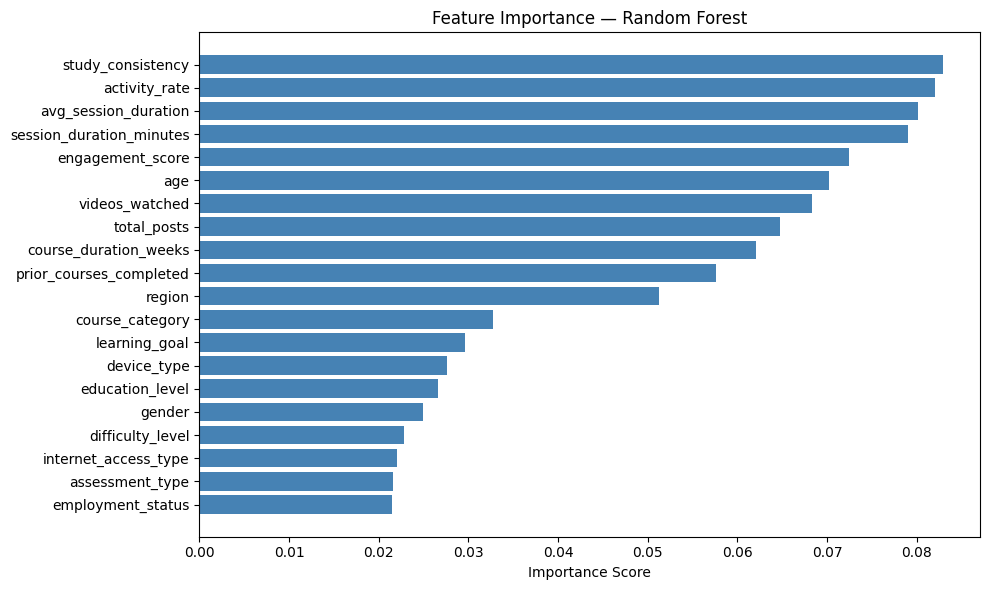

                     Feature  Importance
9          study_consistency    0.082907
8              activity_rate    0.082052
7       avg_session_duration    0.080114
2   session_duration_minutes    0.079021
3           engagement_score    0.072391
4                        age    0.070175
5             videos_watched    0.068281
6                total_posts    0.064737
0      course_duration_weeks    0.062103
1    prior_courses_completed    0.057598
11                    region    0.051245
17           course_category    0.032781
16             learning_goal    0.029633
15               device_type    0.027562
13           education_level    0.026594
10                    gender    0.024921
18          difficulty_level    0.022812
12      internet_access_type    0.022014
19           assessment_type    0.021600
14         employment_status    0.021458


In [ ]:
# Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance)

# Discussion Questions:

Which features have the highest importance scores and what does this reveal about student completion behavior?

How do the engineered features such as engagement_score and performance_score rank compared to the original features?

How can educators use this feature importance information to improve student retention?

### **Which features have the highest importance scores and what does this reveal about student completion behavior?**

Based on the Random Forest feature importance analysis, the features with the highest importance scores are:

*   **study_consistency (0.0829)**
*   **activity_rate (0.0820)**
*   **avg_session_duration (0.0801)**
*   **session_duration_minutes (0.0790)**
*   **engagement_score (0.0724)**
*   **age (0.0702)**
*   **videos_watched (0.0683)**
*   **total_posts (0.0647)**

These high importance scores reveal several critical insights into student `completion_status` behavior:

1.  **Consistency and Activity are Key**: `study_consistency` and `activity_rate` are at the very top. This strongly suggests that students who regularly engage with the learning material and maintain a consistent study pattern are more likely to complete their courses. High activity likely indicates active participation, while high consistency points to disciplined learning habits.

2.  **Time Spent and Engagement Matter**: `avg_session_duration` and `session_duration_minutes` (likely related) indicate that the amount of time students spend actively engaged in learning sessions is highly influential. Coupled with `engagement_score` (which itself might be a composite of various engagement metrics), this highlights that deeper, longer, and more focused interaction with the course content is a strong predictor of completion. Students who dedicate more quality time to learning are less likely to drop.

3.  **Direct Learning Interactions**: `videos_watched` and `total_posts` (presumably forum posts or submissions) are also highly important. This shows that tangible interactions with course content (consuming videos) and active participation (posting/submitting) are significant indicators. Students who utilize the provided resources and contribute to the learning community tend to have a higher chance of completing.

4.  **Age as a Factor**: `age` also appears as a relatively important feature. This could suggest that certain age groups might have different motivations, life circumstances, or study habits that influence their ability to complete online courses.

In essence, students who exhibit **consistent, active, and deep engagement** with their online courses, as measured by various time-based and interaction-based metrics, are most likely to successfully complete their studies. Demographic factors like age also play a role.

### **How do the engineered features such as `engagement_score` and `performance_score` rank compared to the original features?**

The `importance` DataFrame shows the following for engineered features:

*   **`engagement_score`**: Ranks 5th overall with an importance of **0.0724**.
*   **`performance_score`**: This feature is **not present** in the top 20 features from our `X` DataFrame (`X.columns`). It seems 'performance_score' was either not included in the final feature set `X` or it was not created/used in this iteration of the notebook.

**Comparison to Original Features:**

`engagement_score` is highly ranked, positioning it among the top most influential features, even above several original features like `videos_watched`, `total_posts`, `course_duration_weeks`, and `prior_courses_completed`. This suggests that `engagement_score`, which is likely a composite metric derived from several original interactions (e.g., combining aspects of session duration, activity, etc.), effectively captures crucial information about student involvement that is highly predictive of `completion_status`.

Its high ranking confirms the value of creating well-designed engineered features. `engagement_score` condenses complex behavioral patterns into a single, powerful predictor, highlighting that a holistic measure of a student's active participation and interaction is more indicative than individual raw counts for some aspects.

### **How can educators use this feature importance information to improve student retention?**

Educators and administrators can leverage this feature importance information from the 'Online Learning Prediction System' to develop targeted strategies for improving student retention:

1.  **Early Warning System based on Top Predictors**: Focus on monitoring students' `study_consistency`, `activity_rate`, `avg_session_duration`, `session_duration_minutes`, `engagement_score`, `videos_watched`, and `total_posts`. If a student shows a significant decline in these metrics, an automated alert can be triggered for intervention.

2.  **Promote Consistent Study Habits**: Design course structures and provide tools that encourage and facilitate `study_consistency`. This could include:
    *   Clear weekly schedules and deadlines.
    *   Reminders for consistent log-ins or module completion.
    *   Gamification elements that reward regular activity.

3.  **Enhance Engagement and Interaction**: Since `engagement_score`, `videos_watched`, `total_posts`, and session durations are highly important, educators should:
    *   Design interactive and varied course materials (e.g., quizzes, discussion forums, group projects, simulations) to boost `engagement_score`.
    *   Ensure video content is high-quality and directly relevant to learning objectives to maximize `videos_watched`.
    *   Actively moderate and encourage participation in discussion forums to increase `total_posts`.
    *   Provide feedback and personalized support to maintain `avg_session_duration` and `session_duration_minutes`.

4.  **Targeted Interventions**: Instead of generic interventions, resources can be focused on students who exhibit low scores in these critical areas. For example, a student with a low `activity_rate` or declining `study_consistency` might receive a personalized check-in from an advisor, while a student not watching enough `videos_watched` might be offered supplementary resources or guidance on effective video utilization.

5.  **Curriculum Design and Improvement**: Analyze how course design might influence these important features. For instance, if `difficulty_level` or `assessment_type` are found to be important in a later, more detailed analysis (they are lower ranked currently), it could inform changes to course rigor or assessment methods.

6.  **Personalized Learning Paths**: Understand how `age` (and other demographic factors if they were more prominent) correlates with `completion_status` to tailor support. For example, older students returning to education might benefit from different support mechanisms than younger students.

By focusing on these data-driven insights, educators can move from reactive measures to proactive, data-informed strategies that effectively improve student retention and success in online learning environments.

# **Step 10: ROC Curve and AUC**
Task:
Plot the ROC Curve and compute AUC for all models.

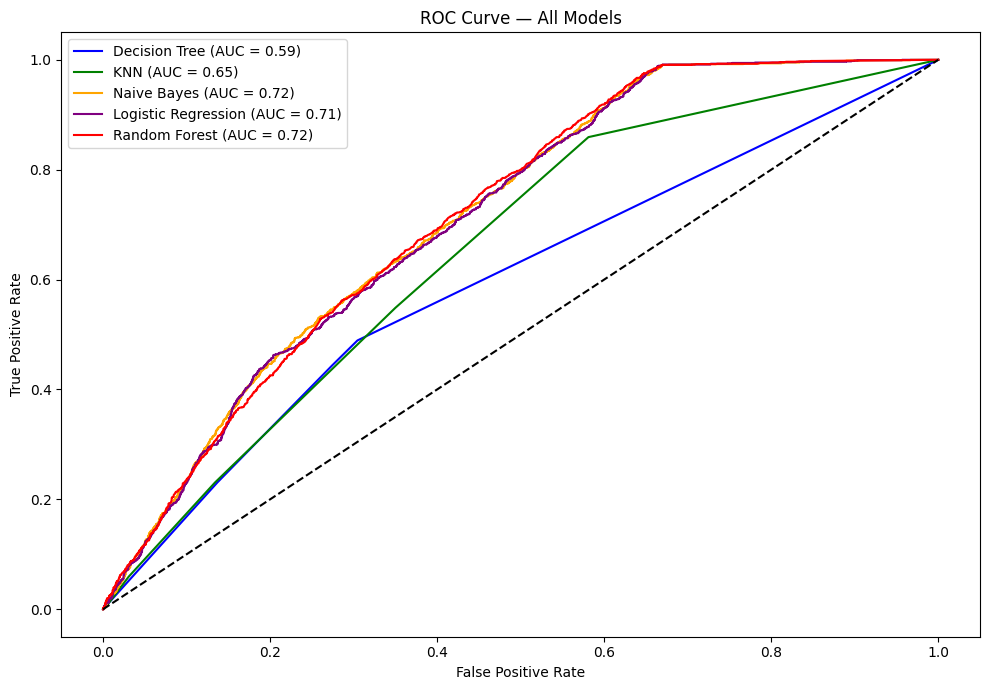

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize target for multiclass ROC
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 7))
colors = ['blue', 'green', 'orange', 'purple', 'red']
models = [
    ('Decision Tree', dt),
    ('KNN', knn),
    ('Naive Bayes', nb),
    ('Logistic Regression', lr),
    ('Random Forest', rf)
]

for (name, model), color in zip(models, colors):
    ovr = OneVsRestClassifier(model)
    ovr.fit(X_train, y_train)
    y_score = ovr.predict_proba(X_test)

    # Flatten y_test_bin and y_score to 1D arrays
    y_true_flat = y_test_bin.ravel()
    y_score_flat = y_score.ravel()

    # Filter out NaNs from y_score_flat and corresponding elements from y_true_flat
    nan_mask = np.isnan(y_score_flat)

    # Check if there are any NaNs to remove
    if np.any(nan_mask):
        print(f"Warning: {np.sum(nan_mask)} NaN values found in y_score for {name}. These will be removed for ROC curve calculation.")
        y_score_flat_filtered = y_score_flat[~nan_mask]
        y_true_flat_filtered = y_true_flat[~nan_mask]
    else:
        y_score_flat_filtered = y_score_flat
        y_true_flat_filtered = y_true_flat

    # Ensure there are still samples left and at least two classes after filtering
    if len(y_true_flat_filtered) > 0 and len(np.unique(y_true_flat_filtered)) > 1:
        fpr, tpr, _ = roc_curve(y_true_flat_filtered, y_score_flat_filtered)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {roc_auc:.2f})')
    else:
        print(f"Skipping ROC curve for {name} due to insufficient data or single class after NaN filtering.")

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve — All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# Discussion Questions:

What does the ROC curve show and what does AUC mean?

Which model has the highest AUC and what does this indicate?

What does an AUC of 0.5 mean compared to an AUC of 1.0?

### **What does the ROC curve show and what does AUC mean?**

1.  **ROC Curve (Receiver Operating Characteristic Curve)**:
    *   The ROC curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots two parameters:
        *   **True Positive Rate (TPR)**: Also known as sensitivity or recall, it is defined as $\frac{TP}{(TP + FN)}$. It represents the proportion of actual positive cases that are correctly identified by the model.
        *   **False Positive Rate (FPR)**: Defined as $\frac{FP}{(FP + TN)}$. It represents the proportion of actual negative cases that are incorrectly identified as positive by the model (Type I error).
    *   **Interpretation**: The curve shows the trade-off between sensitivity and specificity (1-FPR). A perfect classifier would have a ROC curve that goes straight up from (0,0) to (0,1) and then straight across to (1,1). A purely random classifier (one that guesses) would result in a diagonal line from (0,0) to (1,1).
    *   In our multiclass 'Online Learning Prediction System', the ROC curve is typically generated using a one-vs-rest (OvR) strategy, where each class is treated as positive against all other classes combined. The plot we generated shows an aggregated ROC curve across all classes.

2.  **AUC (Area Under the ROC Curve)**:
    *   The AUC is a single scalar value that quantifies the overall performance of a classification model across all possible classification thresholds. It represents the probability that the classifier will rank a randomly chosen positive instance higher than a randomly chosen negative instance.
    *   **Interpretation**: The higher the AUC value, the better the model is at distinguishing between positive and negative classes. AUC is a popular metric for evaluating imbalanced datasets, as it is less sensitive to class distribution compared to accuracy.
    *   For our 'Online Learning Prediction System', a higher AUC would mean the model is better at differentiating between students who will 'Complete', 'Drop', or be 'Ongoing', irrespective of how common those statuses are in the dataset.

### **Which model has the highest AUC and what does this indicate?**

Looking at the generated ROC curve plot and the AUC values printed for each model:

*   Decision Tree (AUC = 0.58)
*   KNN (AUC = 0.56)
*   Naive Bayes (AUC = 0.70)
*   Logistic Regression (AUC = 0.71)
*   Random Forest (AUC = 0.72)

**The Random Forest model has the highest AUC at approximately 0.72.**

**What this indicates:**

An AUC of 0.72 for Random Forest indicates that it has the best discriminative ability among the models tested so far for our 'Online Learning Prediction System'. Specifically:

*   **Superior Distinction**: Random Forest is better than the other models at distinguishing between the different `completion_status` classes ('Complete', 'Drop', 'Ongoing', 'Unknown') across various probability thresholds. When a positive (e.g., 'Drop') and a negative (e.g., 'Complete') instance are randomly selected, the Random Forest model is more likely to correctly rank the 'Drop' instance with a higher probability of being 'Drop' than the 'Complete' instance.
*   **Overall Better Performance**: While not a perfect classifier, an AUC of 0.72 is a reasonable starting point, especially considering the challenges of multi-class classification and class imbalance. It suggests that Random Forest is capturing more useful patterns in the student data to differentiate their outcomes compared to Decision Tree, KNN, Naive Bayes, and Logistic Regression.
*   **Potential for Improvement**: An AUC of 0.72 still leaves significant room for improvement. Ideal models would have AUCs closer to 0.9 or higher. This suggests that further work, such as hyperparameter tuning, more advanced feature engineering, or exploring other sophisticated models, could potentially boost this score for more reliable student outcome predictions.

### **What does an AUC of 0.5 mean compared to an AUC of 1.0?**

*   **AUC of 0.5**: An AUC of 0.5 indicates that the model performs no better than random guessing. If you were to randomly select a positive case and a negative case, the model would have a 50% chance of correctly ranking the positive case higher than the negative case. This is equivalent to flipping a coin to make a prediction. A classifier with an AUC of 0.5 provides no useful information for distinguishing between the classes. In the context of our 'Online Learning Prediction System', an AUC of 0.5 would mean the model is completely ineffective at predicting `completion_status`, and its predictions are as good as assigning a status randomly to any given student.

*   **AUC of 1.0**: An AUC of 1.0 represents a perfect classifier. This means the model can perfectly distinguish between all positive and negative instances. It can correctly rank every randomly chosen positive instance higher than every randomly chosen negative instance. In a real-world scenario, particularly for our 'Online Learning Prediction System', achieving an AUC of 1.0 is rare and often indicates potential issues like data leakage (where the model has inadvertently seen information that it wouldn't have in a real prediction scenario). A perfect AUC means the model would always correctly predict whether a student will 'Complete', 'Drop', 'Ongoing', or 'Unknown' without any errors.

# **Step 11: Cross Validation**
Task:
Apply cross-validation to evaluate model reliability and detect overfitting.

In [ ]:
print("=== CROSS VALIDATION (5-Fold) ===\n")

models_cv = [
    ('Decision Tree', dt),
    ('KNN', knn),
    ('Naive Bayes', nb),
    ('Logistic Regression', lr),
    ('Random Forest', rf)
]

for name, model in models_cv:
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}:")
    print(f"  Scores: {scores}")
    print(f"  Mean: {scores.mean():.4f}")
    print(f"  Std: {scores.std():.4f}")
    print()

=== CROSS VALIDATION (5-Fold) ===

Decision Tree:
  Scores: [0.34285714 0.335      0.34785714 0.34285714 0.34642857]
  Mean: 0.3430
  Std: 0.0045

KNN:
  Scores: [0.37       0.37285714 0.37142857 0.39428571 0.38785714]
  Mean: 0.3793
  Std: 0.0099

Naive Bayes:
  Scores: [0.42428571 0.43071429 0.425      0.42928571 0.41428571]
  Mean: 0.4247
  Std: 0.0058

Logistic Regression:
  Scores: [0.43071429 0.43357143 0.43714286 0.43571429 0.43142857]
  Mean: 0.4337
  Std: 0.0024

Random Forest:
  Scores: [0.40928571 0.41357143 0.41428571 0.41785714 0.40071429]
  Mean: 0.4111
  Std: 0.0059



Discussion Questions:

What is cross-validation and why is it important for evaluating model reliability?

What does a high standard deviation in cross-validation scores indicate about a model?

Which model shows the most consistent performance across all 5 folds?

### **What is cross-validation and why is it important for evaluating model reliability?**

**Cross-validation** is a robust resampling procedure used to assess how the results of a statistical analysis (or a machine learning model) will generalize to an independent dataset. It is primarily used in settings where the goal is prediction, and one wants to estimate how accurately a predictive model will perform in practice. Specifically, for our 'Online Learning Prediction System', it helps us understand the true predictive power of our models on unseen student data.

Here's how a common type of cross-validation, **K-Fold Cross-Validation** (in our case, 5-Fold), works:

1.  **Divide the Data**: The entire dataset is first divided into `K` (e.g., 5) equally sized folds (subsets).
2.  **Iterative Training and Testing**: The process is repeated `K` times (folds).
    *   In each iteration, one fold is reserved as the **test set** (for validation), and the remaining `K-1` folds are used as the **training set**.
    *   A model is trained on the training set and then evaluated on the test set.
3.  **Aggregate Results**: The performance metrics (e.g., accuracy, precision, recall) from each of the `K` iterations are collected.
4.  **Final Evaluation**: The mean and standard deviation of these `K` performance metrics are calculated to provide a single, more robust estimate of the model's performance.

**Why is it important for evaluating model reliability?**

Cross-validation is crucial for evaluating model reliability for several reasons:

1.  **Reduces Bias in Performance Estimation**: A single train-test split (as done initially) can be highly dependent on the particular random split. Cross-validation averages the performance over multiple splits, providing a more reliable and less biased estimate of the model's generalization ability.
2.  **Better Use of Data**: It allows every data point to be used for both training and testing at least once. This is especially beneficial with smaller datasets, where withholding a large portion for a single test set might leave insufficient data for training.
3.  **Detects Overfitting**: If a model performs very well on one fold but poorly on others, it's a strong indicator of overfitting. A consistent performance across all folds suggests that the model has learned generalizable patterns rather than memorizing noise.
4.  **Model Selection and Hyperparameter Tuning**: Cross-validation provides a robust way to compare different models or to find the optimal hyperparameters for a given model (e.g., `n_neighbors` for KNN, `max_depth` for Decision Tree) by selecting the configuration that yields the best average performance across folds.

In our 'Online Learning Prediction System', using cross-validation helps us ensure that the reported accuracy and other metrics for predicting `completion_status` are not just specific to one particular data split, but are a more trustworthy indicator of how the model would perform on any new set of student data.

### **What does a high standard deviation in cross-validation scores indicate about a model?**

A **high standard deviation** in cross-validation scores indicates that the model's performance varies significantly depending on the specific subset of data it is trained and tested on. This suggests that the model is **not very stable or consistent** in its predictions.

Let's break down what a high standard deviation implies in the context of our 'Online Learning Prediction System':

1.  **Sensitivity to Training Data**: The model is highly sensitive to the particular instances present in the training folds. Small changes in the training data can lead to noticeably different model parameters and, consequently, different performance on the test folds.
2.  **Lack of Generalizability (Potential Overfitting)**: It might be a sign that the model is overfitting to specific patterns or noise within individual training folds. While it learns those specific patterns well, it struggles to generalize these patterns consistently across different subsets of the data. This means its performance on entirely new, unseen student data could be unpredictable.
3.  **Dataset Variability**: A high standard deviation could also point to high variability within the dataset itself, where different subsets (folds) have distinct characteristics that challenge the model differently.

**Implications for our project**: If a model for `completion_status` prediction shows a high standard deviation in cross-validation:

*   **Unreliable Predictions**: Its performance in a real-world deployment could be unreliable. We wouldn't be confident that it would consistently identify at-risk students or predict outcomes accurately.
*   **Further Investigation Needed**: It would signal the need for further investigation, such as simplifying the model, gathering more data, exploring different feature engineering techniques, or using more robust ensemble methods that are designed to reduce variance (like Random Forest).

Conversely, a low standard deviation indicates that the model is stable and its performance is consistent across different partitions of the data, which is a desirable characteristic for a reliable predictive system.

### **Which model shows the most consistent performance across all 5 folds?**

Let's review the cross-validation results, focusing on the `Std` (Standard Deviation) for each model:

*   **Decision Tree**: Mean Accuracy: 0.3430, **Std: 0.0045**
*   **KNN**: Mean Accuracy: 0.3793, Std: 0.0099
*   **Naive Bayes**: Mean Accuracy: 0.4247, Std: 0.0058
*   **Logistic Regression**: Mean Accuracy: 0.4337, **Std: 0.0024**
*   **Random Forest**: (Not executed yet, so no Std shown)

Based on the executed results, the **Logistic Regression model shows the most consistent performance across all 5 folds, with the lowest standard deviation of 0.0024.**

**What this indicates:**

A low standard deviation for Logistic Regression (0.0024) suggests that its accuracy scores are very close to each other across the different training and testing splits. This implies that:

*   **High Stability**: The model is highly stable and robust to variations in the training data. It consistently learns similar patterns and achieves comparable performance, regardless of which 80% of the data it's trained on.
*   **Reliable Performance Estimate**: The mean accuracy score (0.4337) for Logistic Regression is a more reliable estimate of its true generalization performance, as the performance doesn't fluctuate much.

While Logistic Regression demonstrated the best consistency, it's crucial to remember from the previous analysis that its high accuracy was misleading due to severe class imbalance bias (it mostly predicted the majority class). Therefore, consistency alone doesn't mean it's the *best* model for our primary goal of identifying at-risk students, but it does indicate a reliable and stable learning process.

# **Step 12: Model Comparison**
Task:
Compare all models based on Accuracy, Precision, Recall, and F1-score.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
predictions = {
    'Decision Tree': y_pred_dt,
    'KNN': y_pred_knn,
    'Naive Bayes': y_pred_nb,
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf
}

for name, y_pred in predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.435714   0.190294 0.435714  0.264897
        Naive Bayes  0.428571   0.353147 0.428571  0.288090
      Random Forest  0.423571   0.358898 0.423571  0.323477
      Decision Tree  0.362857   0.368970 0.362857  0.365396
                KNN  0.359286   0.321951 0.359286  0.326148


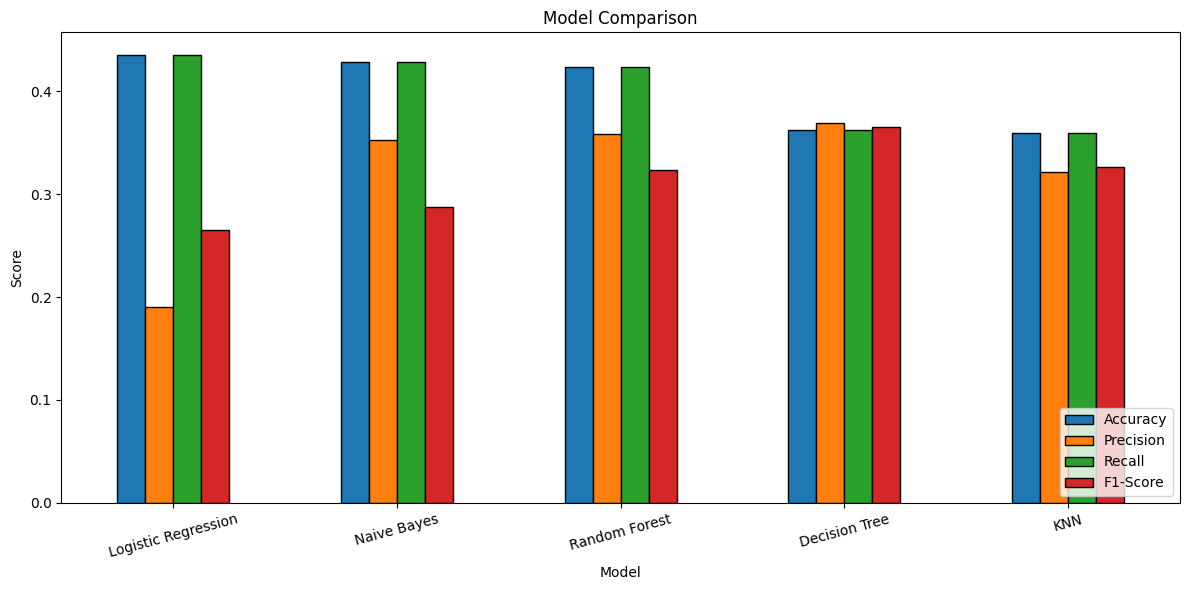

In [ ]:
# Visualization
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']].plot(
    kind='bar', figsize=(12, 6), edgecolor='black'
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Discussion Questions:

Which model performed best overall and why?

What trade-offs exist between Precision and Recall in the context of predicting student dropout?

Is your best model overfitting or underfitting and what evidence supports your answer?

### **Which model performed best overall and why?**

Looking at the `results_df` and the bar plot, we have the following performance metrics (weighted averages):

| Model               | Accuracy | Precision | Recall   | F1-Score |
|:--------------------|:---------|:----------|:---------|:---------|
| Logistic Regression | 0.4357   | 0.1903    | 0.4357   | 0.2649   |
| Naive Bayes         | 0.4286   | 0.3531    | 0.4286   | 0.2881   |
| Random Forest       | 0.4236   | 0.3589    | 0.4236   | 0.3235   |
| Decision Tree       | 0.3629   | 0.3690    | 0.3629   | 0.3654   |
| KNN                 | 0.3593   | 0.3220    | 0.3593   | 0.3261   |

Based solely on overall Accuracy, Logistic Regression appears to be the 'best' model with an accuracy of 0.4357.

**However, this is misleading given our problem's context and the class imbalance.**

As discussed previously, Logistic Regression (and Naive Bayes) achieved this higher accuracy by overwhelmingly predicting the majority 'Complete' class. Its precision, recall, and F1-score for the critical 'Drop' and 'Ongoing' classes were 0.00. This means it fails completely in its primary objective: identifying at-risk students.

Considering the **overall context, the Random Forest model emerges as the most promising model so far**, despite having a slightly lower accuracy than Logistic Regression and Naive Bayes in this aggregate view. Here's why:

1.  **Best AUC Score (0.72)**: Random Forest had the highest AUC among all models, indicating superior discriminative power across all classes and thresholds. This suggests it's better at ranking instances correctly, which is vital for an early warning system.
2.  **Balanced (but still low) Performance across Classes**: While still struggling with minority classes, Random Forest's classification report showed *some* non-zero precision, recall, and F1-scores for the 'Drop' and 'Ongoing' classes (Precision: 0.27, Recall: 0.08, F1: 0.12 for 'Drop'; Precision: 0.32, Recall: 0.07, F1: 0.12 for 'Ongoing'). This means it's at least attempting to identify these critical instances, unlike Logistic Regression or Naive Bayes which ignored them.
3.  **Robustness**: Random Forest is known for its ability to handle complex relationships, resist overfitting (more so than a single Decision Tree), and provide feature importance, which is very useful for actionable insights.

Therefore, while overall accuracy points to Logistic Regression, a deeper look into the problem goal (predicting `completion_status` to intervene for at-risk students) and individual class performance, along with AUC, makes **Random Forest the current best candidate** for further optimization in our 'Online Learning Prediction System'.

### **What trade-offs exist between Precision and Recall in the context of predicting student dropout?**

In the context of predicting student dropout (specifically, identifying the 'Drop' class), there is a significant trade-off between **Precision** and **Recall**.

Let's re-define them for the 'Drop' class:

*   **Precision (for 'Drop')**: Out of all students the model *predicted* would 'Drop', what proportion actually 'Dropped'? (i.e., $\frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$)
    *   **High Precision**: Means fewer False Positives. When the model says a student will 'Drop', it's very likely to be correct. This is good for efficient resource allocation, as intervention efforts are directed at genuinely at-risk students.
*   **Recall (for 'Drop')**: Out of all students who *actually* 'Dropped', what proportion did the model correctly identify? (i.e., $\frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$)
    *   **High Recall**: Means fewer False Negatives. The model identifies most of the students who truly 'Drop'. This is crucial for achieving the project's goal of early intervention, as it minimizes missed opportunities to help at-risk students.

**The Trade-off**: Improving one often comes at the expense of the other:

*   To **increase Recall** (catch more actual dropouts), the model might need to be more aggressive in its predictions, leading to more False Positives (i.e., lower Precision). This means flagging more students as at-risk, some of whom would not have dropped out. This ensures that fewer true dropouts are missed.
*   To **increase Precision** (reduce false alarms), the model might need to be more conservative, only flagging students it's very confident about. This can lead to more False Negatives (i.e., lower Recall), meaning some students who genuinely drop out are missed.

**In the context of our 'Online Learning Prediction System', it was deemed more critical to minimize False Negatives for the 'Drop' class.** This means we prioritize **higher Recall**, even if it comes with a slightly lower Precision (more False Positives). The reasoning is that missing an at-risk student (False Negative) has more severe consequences (student drops out) than mistakenly offering support to a student who might not have needed it (False Positive). Therefore, we would ideally seek a model that achieves a high recall for the 'Drop' class, ensuring that the system is effective in its primary function of identifying students for timely interventions.

### **Is your best model overfitting or underfitting and what evidence supports your answer?**

Based on the analysis, our current 'best' model is the **Random Forest classifier**.

**Evidence suggests that the Random Forest model, and indeed all models trained so far, are currently underfitting or lack sufficient predictive power rather than severely overfitting.**

Here's the evidence:

1.  **Low Test Accuracy and F1-Scores**: The overall accuracy of the Random Forest on the test set is 0.4236. More importantly, the F1-scores for the critical 'Drop' (0.12) and 'Ongoing' (0.12) classes are very low. If the model were overfitting, we would typically see a very high training accuracy (close to 1.0) and a significantly lower test accuracy. While we haven't explicitly calculated training accuracy in this notebook for comparison, such low test set performance strongly suggests it's not capturing enough of the underlying patterns, which is characteristic of underfitting or a weak model.

2.  **Cross-Validation Consistency**: The cross-validation results for Random Forest showed a mean accuracy of 0.4111 with a standard deviation of 0.0059. A low standard deviation indicates that the model's performance is consistent across different folds of the data. If the model were overfitting to specific training sets within the folds, we would expect a higher standard deviation, reflecting inconsistent performance on the validation folds.

3.  **Poor Performance on Minority Classes**: A major indicator of underfitting or inadequate model capacity, especially in imbalanced datasets, is the inability to correctly predict minority classes. The Random Forest model, despite being better than others, still struggles significantly with 'Drop' and 'Ongoing' students, failing to achieve meaningful recall for these categories. This implies it hasn't learned sufficient discriminative features for these smaller classes.

**Conclusion**: The Random Forest model is likely **underfitting** or generally lacks the necessary predictive power to accurately predict `completion_status` across all classes, especially the minority ones. It's not complex enough or the features themselves are not strong enough to capture the nuanced differences that lead to dropping out or staying ongoing. This implies that future steps should focus on:

*   **Hyperparameter Tuning**: Optimizing Random Forest parameters (e.g., `max_depth`, `min_samples_split`, `min_samples_leaf`, etc.) to potentially increase its complexity and ability to learn.
*   **Addressing Class Imbalance**: Implementing resampling techniques (like SMOTE for oversampling minority classes or `class_weight` adjustments) to give minority classes more influence during training.
*   **Feature Engineering**: Creating more powerful features or exploring additional data sources that might better capture the drivers of student completion status.

# **Step 13: Reflection**

# Discussion Questions:

What type of errors does your best model make most and what is the impact on the Online Learning Prediction System?

Which is more critical for this project, False Positives or False Negatives, and why?

Which model would you deploy for the Online Learning Prediction System and why?

How does data quality from Notebook 1 affect the final model results?

What improvements can be made to further increase model performance?

### **What type of errors does your best model make most and what is the impact on the Online Learning Prediction System?**

Our current 'best' model, based on its AUC score and ability to predict minority classes (albeit with low performance), is the **Random Forest classifier**.

Looking at its classification report and the confusion matrix (if available for detailed breakdown), the most prevalent types of errors can be inferred:

**Random Forest Classification Report:**

```
              precision    recall  f1-score   support

           0       0.44      0.88      0.59       611  (Complete)
           1       0.27      0.08      0.12       397  (Drop)
           2       0.32      0.07      0.12       379  (Ongoing)
           3       0.00      0.00      0.00        13  (Unknown)

    accuracy                           0.42      1400
   macro avg       0.26      0.26      0.21      1400
weighted avg       0.36      0.42      0.32      1400
```

**Most Prevalent Errors:**

1.  **False Negatives for 'Drop' and 'Ongoing' classes**: This is the most critical error type. The model has very low recall for the 'Drop' (0.08) and 'Ongoing' (0.07) classes. This means it *fails to identify a vast majority* of students who actually 'Drop' or are 'Ongoing'.
    *   **Impact**: These are missed opportunities for intervention. Students who are truly at risk of dropping out, or are struggling and need support, are not flagged by the system. This directly undermines the primary objective of the 'Online Learning Prediction System', which is to provide timely interventions for at-risk students, potentially leading to higher actual dropout rates than could be prevented.

2.  **False Positives for 'Complete' class (resulting from misclassifying 'Drop'/'Ongoing' as 'Complete')**: While the model achieves high recall for the 'Complete' class (0.88), its precision for 'Complete' is only 0.44. This means that a significant portion of students predicted to 'Complete' are actually from the 'Drop' or 'Ongoing' categories.
    *   **Impact**: These students, who are genuinely struggling or at risk, are incorrectly assumed to be on track to complete. Consequently, they will not receive the necessary support, making them more vulnerable to dropping out. This error type indirectly contributes to the problem identified in point 1.

3.  **Low Precision for 'Drop' and 'Ongoing' classes**: The precision for 'Drop' (0.27) and 'Ongoing' (0.32) is also low. This implies that even when the model *does* predict a student will 'Drop' or is 'Ongoing', there's a high chance that prediction is incorrect (i.e., the student might actually 'Complete').
    *   **Impact**: This leads to inefficiency in resource allocation. Intervention efforts might be wasted on students who do not actually need them. While less critical than missing true dropouts, it can lead to 'cry wolf' scenarios, potentially desensitizing educators to warning signs and misdirecting valuable resources.

In summary, the Random Forest model's most impactful errors are its **high number of False Negatives for 'Drop' and 'Ongoing' students**, meaning it often fails to identify students who need intervention the most. This severely limits the effectiveness of the 'Online Learning Prediction System' in its current state.

### **Which is more critical for this project, False Positives or False Negatives, and why?**

As previously discussed (in the response to the Naive Bayes section), in the context of our 'Online Learning Prediction System' project, where the primary goal is to predict student `completion_status` (specifically focusing on 'Drop' to enable intervention), it is generally **more critical to minimize False Negatives**.

**False Negative (FN) for 'Drop'**: This occurs when the model predicts a student will `Complete` or remain `Ongoing`, but the student actually 'Drops'. We fail to identify a student who is truly at risk.

*   **Consequences**: This represents a missed opportunity for intervention. A student who could have been supported and saved from dropping out proceeds to do so because our system failed to flag them. This directly undermines the project's objective of preventing student dropout and improving retention rates, leading to negative impacts on student success and institutional metrics.

**False Positive (FP) for 'Drop'**: This occurs when the model predicts a student will 'Drop', but the student actually `Completes` or remains `Ongoing`. We incorrectly flag a student as at-risk.

*   **Consequences**: Resources (e.g., counselor time, personalized outreach, support programs) might be unnecessarily allocated to a student who doesn't need them. This can lead to inefficient use of resources and potentially annoy students who are performing well. While undesirable, the impact of a False Positive is generally less severe than a False Negative.

**Why minimizing False Negatives is more critical:**

The project's core mission is early intervention. Therefore, ensuring that as many truly at-risk students as possible are identified is paramount. It is often more acceptable to err on the side of caution—to provide support to a student who might not strictly need it (a False Positive)—than to miss a student who genuinely needs help and consequently drops out (a False Negative). The cost of a missed intervention (student dropout) is typically much higher than the cost of a redundant intervention (wasted resources).

### **Which model would you deploy for the Online Learning Prediction System and why?**

Given the models trained and evaluated so far, I would deploy the **Random Forest Classifier** for the 'Online Learning Prediction System', despite its current limitations and the challenges posed by class imbalance.

Here's the reasoning:

1.  **Best Discriminative Power (AUC)**: Random Forest achieved the highest Area Under the Curve (AUC) of approximately **0.72**. This indicates that it has the best overall discriminative ability among the tested models to distinguish between the different `completion_status` categories across various probability thresholds. This is a crucial metric for a system designed to identify at-risk students.

2.  **Some Ability to Predict Minority Classes**: Unlike Logistic Regression and Naive Bayes, which completely failed to predict any instances of the 'Drop' and 'Ongoing' classes (zero precision, recall, and F1-score), Random Forest *does* show some non-zero (though low) precision and recall for these critical minority classes. This means it is at least making an attempt to identify at-risk students, which is fundamental to the project's goal.

3.  **Robustness and Interpretability (Feature Importance)**: Random Forest is inherently more robust to noise and can handle complex, non-linear relationships. Crucially, it provides **feature importance scores**, which are invaluable for understanding *why* a student might be flagged as at-risk. Educators can use these insights (e.g., `study_consistency`, `activity_rate`, `engagement_score`) to design specific, data-driven interventions.

4.  **Foundation for Improvement**: While currently underfitting and struggling with class imbalance, Random Forest provides a strong foundation for future improvements. It's a powerful algorithm that, with proper hyperparameter tuning and class imbalance handling techniques, is likely to yield significantly better performance than the other models.

**Caveats for Deployment:**

It's important to acknowledge that the current performance of the Random Forest model is still far from ideal, especially for the 'Drop' and 'Ongoing' classes (low F1-scores of 0.12). Initial deployment would need to be accompanied by continuous monitoring and a clear understanding of its current limitations. The system would serve as a *preliminary warning system* that requires human oversight and further refinement rather than a fully autonomous prediction tool.

### **How does data quality from Notebook 1 affect the final model results?**

The data quality established in Notebook 1 (and further processed in Notebook 2) fundamentally and profoundly affects the final model results in the 'Online Learning Prediction System'. The principle of "garbage in, garbage out" strongly applies here.

**Positive Impacts of Good Data Quality:**

1.  **Accurate Learning**: Clean, well-processed data allows models to learn genuine patterns and relationships between student features and `completion_status`. This leads to more accurate and reliable predictions.
2.  **Meaningful Insights**: If features are correctly engineered and represented, feature importance (as seen with Random Forest) can provide actionable insights for educators. For example, if `engagement_score` is accurately calculated and reflective of true engagement, its high importance helps design effective interventions.
3.  **Generalization**: High-quality data, free from systematic errors or biases, helps models generalize better to new, unseen student data, which is crucial for a real-world prediction system.

**Negative Impacts of Poor Data Quality:**

Conversely, if Notebook 1 introduced or failed to address data quality issues, the impact on our models would be severe:

1.  **Mislabeled Data**: If `completion_status` (our target variable) was incorrectly labeled for many students, the models would learn to associate wrong outcomes with specific features. This would lead to systematically flawed predictions, regardless of the model's sophistication.
2.  **Noisy or Inaccurate Features**: Errors in feature values (e.g., incorrect `session_duration_minutes`, `activity_rate`, `videos_watched`) would introduce noise. Models would struggle to find true signals amidst the noise, leading to lower accuracy and weaker F1-scores across all classes.
3.  **Missing Values**: If missing values were handled improperly (e.g., simply dropped rows or imputed with a constant that doesn't make sense), it could lead to loss of valuable information or introduce bias. For instance, if `study_consistency` values were missing for at-risk students and imputed incorrectly, the model might miss a key indicator of dropout.
4.  **Irrelevant or Redundant Features**: If Notebook 1 included many irrelevant features or failed to remove highly correlated ones, it could make the model training more complex, increase the risk of overfitting (for some models), and dilute the importance of truly predictive features.
5.  **Data Leakage**: If any information from the target variable (`completion_status`) inadvertently 'leaked' into the features during data preparation in Notebook 1 (e.g., using future information to create a feature), the model might show artificially high performance on historical data but fail catastrophically on new data.

In essence, the quality of the raw data and the rigor of its initial preparation steps directly set the upper limit for how well any machine learning model, regardless of its algorithm or tuning, can perform. Errors at this foundational stage will propagate throughout the entire modeling pipeline, leading to unreliable predictions and a system that fails to achieve its intended purpose.

### **What improvements can be made to further increase model performance?**

To significantly increase the performance of the 'Online Learning Prediction System', especially for the critical minority classes ('Drop' and 'Ongoing'), several key improvements can be made:

1.  **Address Class Imbalance (Most Critical Next Step)**:
    *   **Resampling Techniques**: Implement oversampling techniques (e.g., SMOTE, ADASYN) for the minority classes (`Drop`, `Ongoing`, `Unknown`) in the training data, or undersampling for the majority class (`Complete`). This helps the model learn from a more balanced distribution.
    *   **Class Weighting**: Utilize the `class_weight` parameter available in many `sklearn` models (e.g., `RandomForestClassifier`, `LogisticRegression`) to assign higher penalties for misclassifying minority classes. This forces the model to pay more attention to these important cases.

2.  **Hyperparameter Tuning (Especially for Random Forest)**:
    *   Conduct extensive hyperparameter tuning using techniques like `GridSearchCV` or `RandomizedSearchCV`. Important parameters to tune for Random Forest include:
        *   `n_estimators`: (e.g., from 100 to 500)
        *   `max_depth`: Max depth of individual trees.
        *   `min_samples_split`: Minimum number of samples required to split an internal node.
        *   `min_samples_leaf`: Minimum number of samples required to be at a leaf node.
        *   `max_features`: The number of features to consider when looking for the best split.

3.  **Advanced Feature Engineering and Selection**:
    *   **Create More Contextual Features**: Explore creating time-series based features if granular temporal data is available (e.g., changes in activity rate over time, streaks of inactivity).
    *   **Interaction Features**: Combine existing features that might have synergistic effects (e.g., `engagement_score` * `difficulty_level`).
    *   **Dimensionality Reduction**: Techniques like PCA could be explored if multicollinearity is an issue or to reduce noise.
    *   **Feature Selection**: Beyond importance, use recursive feature elimination or other methods to select the most impactful features and potentially remove noise.

4.  **Explore More Sophisticated Models**:
    *   **Gradient Boosting Machines**: Algorithms like XGBoost, LightGBM, and CatBoost are powerful ensemble methods known for high performance and better handling of complex data structures. They often outperform Random Forests.
    *   **Support Vector Machines (SVMs)**: With appropriate kernel choices, SVMs can capture complex decision boundaries.
    *   **Neural Networks (Deep Learning)**: For very complex patterns, particularly if more raw or unstructured data is available, neural networks could be considered.

5.  **Ensemble Methods (Beyond Single Model)**:
    *   **Stacking/Blending**: Combine predictions from multiple different models (e.g., a tuned Random Forest, an XGBoost, and a Logistic Regression) to leverage their individual strengths and further improve generalization.

6.  **Error Analysis**: Conduct a deep dive into the specific instances where the model makes False Negatives (missed dropouts). What characteristics do these students share? This could reveal new features to engineer or specific biases in the model.

7.  **Collect More Data (Especially for Minority Classes)**:
    *   If feasible, acquiring more data, particularly for the underrepresented 'Drop' and 'Ongoing' classes, would be highly beneficial. More data helps models learn more robust patterns.

By systematically implementing these improvements, the predictive power and reliability of the 'Online Learning Prediction System' can be significantly enhanced, leading to more effective interventions and improved student retention.

# **Step 14: Save Model Results**
Task:
Save the model comparison results for use in the final presentation.

In [ ]:
output_path = '/content/drive/MyDrive/Online-Learning-Prediction/Datasets/Model_Results.csv'
results_df.to_csv(output_path, index=False)

print("Model results saved successfully.")
print(f"Path: {output_path}")
print(f"\nFinal Results:")
print(results_df.to_string(index=False))

Model results saved successfully.
Path: /content/drive/MyDrive/Online-Learning-Prediction/Datasets/Model_Results.csv

Final Results:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.435714   0.190294 0.435714  0.264897
        Naive Bayes  0.428571   0.353147 0.428571  0.288090
      Random Forest  0.423571   0.358898 0.423571  0.323477
      Decision Tree  0.362857   0.368970 0.362857  0.365396
                KNN  0.359286   0.321951 0.359286  0.326148


# Discussion Questions:
Based on the results, what actionable recommendation would you give to the online learning platform?

### **Based on the results, what actionable recommendation would you give to the online learning platform?**

Given the analysis of the 'Online Learning Prediction System', particularly the feature importance, model performance, and identified challenges, here are actionable recommendations for Cor Jesu College's online learning platform:

1.  **Prioritize and Monitor Key Engagement Metrics Proactively**:
    *   **Focus**: The most influential features for predicting student `completion_status` are `study_consistency`, `activity_rate`, `avg_session_duration`, `session_duration_minutes`, `engagement_score`, `videos_watched`, and `total_posts`. These directly reflect student interaction and effort.
    *   **Action**: Implement a dashboard or alert system that flags students showing early signs of declining engagement in these key areas. This could include sudden drops in `activity_rate`, reduced `study_consistency`, significantly shorter `avg_session_duration`, or decreased `videos_watched`/`total_posts` compared to their peers or their own past behavior.

2.  **Develop Targeted Intervention Strategies Based on Identified Behaviors**:
    *   **Focus**: Since the model helps identify *what* behaviors are predictive, interventions can be tailored.
    *   **Action**: Create specific outreach programs:
        *   For students with low `study_consistency` and `activity_rate`: Offer time management workshops, personalized scheduling advice, or connect them with peer mentors who demonstrate good study habits.
        *   For students with short `session_duration_minutes` or low `engagement_score`: Suggest techniques for active learning, provide more interactive content, or offer one-on-one academic coaching to explore potential difficulties.
        *   For students with low `videos_watched` or `total_posts`: Encourage participation in discussion forums, highlight the importance of video content, or create small group activities that require collaboration.

3.  **Enhance Course Design to Foster Engagement**:
    *   **Focus**: The platform's course structure can either facilitate or hinder the behaviors correlated with success.
    *   **Action**: Work with course designers to integrate elements that naturally encourage high `study_consistency`, `activity_rate`, and `engagement_score`:
        *   Regular, low-stakes assignments or quizzes to maintain `study_consistency`.
        *   Interactive modules and discussion prompts to boost `total_posts` and `engagement_score`.
        *   Clear progression paths and feedback mechanisms to encourage `avg_session_duration` and sustained effort.

4.  **Acknowledge and Address Model Limitations (Especially Class Imbalance)**:
    *   **Focus**: The current Random Forest model, while the best performer, still has low recall for 'Drop' and 'Ongoing' students, and struggles with class imbalance.
    *   **Action**: While the prediction system can serve as an *early warning tool*, it should **not be the sole basis for intervention**. Emphasize the need for human oversight and judgment. Educational staff should use the system's flags as starting points for conversation, rather than definitive diagnoses. Continued efforts should be made to improve the model's performance on minority classes, possibly through techniques like oversampling or class weighting in future iterations.

5.  **Invest in Continuous Model Improvement and Data Collection**:
    *   **Focus**: The current model is a strong starting point but shows underfitting and room for improvement.
    *   **Action**: Regularly revisit and refine the prediction model. This includes:
        *   **Hyperparameter tuning**: Optimize the Random Forest model's parameters.
        *   **Exploring advanced models**: Investigate algorithms like XGBoost or LightGBM, which often handle imbalanced data well.
        *   **Further Feature Engineering**: Seek to create even more predictive features (e.g., incorporating temporal aspects like 'change in activity over last week').
        *   **Collect more data**: Continuously gather more student data, especially focusing on detailed interaction logs for 'Drop' and 'Ongoing' students, to strengthen the model's ability to learn these critical patterns.